# Stochastic White Noise Analysis (SWNA) with Memory
### Workshop — Hands-on Session

**Package:** `whitenoise` — SWNA with Memory framework (Bernido & Carpio-Bernido)

---

## The Full Pipeline

| Step | Function | What it does |
|---|---|---|
| A | `wn.read_csv()` | Load CSV → time, values, metadata |
| B | `wn.plot_series()` | Plot the raw time series |
| C | `wn.compute_msd()` | Compute empirical MSD |
| D | `wn.plot_msd_raw()` | Inspect the MSD shape |
| E | `wn.fit_msd()` | Fit model → extract μ, R², 95% CIs |
| F | `fit.summary()` | Print the full parameter table |
| G | *(matplotlib)* | Overlay fitted curve on empirical MSD |
| H | *(matplotlib)* | Plot displacement PDF vs theoretical Gaussian |
| I | `wn.analyze()` | Run steps A–H automatically in one call |

---

**The memory parameter μ:**

| μ | Regime | Meaning |
|---|---|---|
| < 0.95 | Subdiffusive | Past fluctuations resist change |
| 0.95–1.05 | Near-Brownian | Weak or no memory |
| 1.05–2.0 | Superdiffusive | Past fluctuations reinforce future ones |
| > 2.0 | Hyperballistic | Strongly persistent dynamics |

---
## Setup — Install and import
Run once at the start of every session.

In [5]:
!pip install git+https://github.com/pnayga/whitenoise.git -q
print('Installation complete.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Installation complete.


In [6]:
import whitenoise as wn
import matplotlib.pyplot as plt
import numpy as np

print(f'whitenoise {wn.__version__} ready.')

whitenoise 0.1.0 ready.


---
## Available models

The package implements 16 models from Table 3.1 of Bernido & Carpio-Bernido (2015).
**You choose the model — the package never auto-selects.**

In [ ]:
wn.list_models()

---
## CSV format

```
time [months], sunspot_number [count]
1, 12.4
2, 15.1
3, 14.8
```

- **Row 1** → header (required)
- **Column 1** → time or index (independent variable)
- **Column 2** → your observable
- Format: `name [unit]` — unit in square brackets
- Unitless: `flux []`

---
## Interactive exploration — how parameters shape the MSD

Before running any analysis, use the sliders below to develop intuition for what each parameter does to the theoretical MSD curve.

- Move **μ** to see the memory regime change
- Move the secondary parameter (**β**, **ν**, or **H**) to see how it modulates the shape
- The **dashed grey line** is the Brownian reference (MSD ∝ T, no memory)
- The **curve color** reflects the regime: 🔵 subdiffusive · 🟢 near-Brownian · 🟠 superdiffusive · 🔴 hyperballistic

### Exponential model — `msd_exponential(T, μ, β)`

$$\text{MSD}(T) = \Gamma(\mu)\cdot\beta^{-\mu}\cdot T^{\mu-1}\cdot e^{-\beta/T}$$

- **μ (mu)** — memory parameter: controls overall diffusion regime
- **β (beta)** — exponential decay rate: controls how quickly memory builds up at small lags (larger β → slower rise)

In [ ]:
from ipywidgets import interact, FloatSlider, Layout

REGIME_COLORS = {
    'Subdiffusive':   '#3498DB',
    'Near-Brownian':  '#2ECC71',
    'Superdiffusive': '#F39C12',
    'Hyperballistic': '#E74C3C',
}

def get_regime(mu):
    if mu < 0.95:   return 'Subdiffusive'
    if mu < 1.05:   return 'Near-Brownian'
    if mu <= 2.0:   return 'Superdiffusive'
    return 'Hyperballistic'

T = np.linspace(0.5, 80, 400)

@interact(
    mu   = FloatSlider(min=0.1, max=3.5, step=0.05, value=1.15,
                       description='μ (mu)', style={'description_width': '90px'},
                       layout=Layout(width='500px')),
    beta = FloatSlider(min=0.01, max=1.5, step=0.01, value=0.1,
                       description='β (beta)', style={'description_width': '90px'},
                       layout=Layout(width='500px')),
    N    = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                       description='N (scale)', style={'description_width': '90px'},
                       layout=Layout(width='500px')),
)
def explore_exponential(mu, beta, N):
    msd = N * wn.get_model('exponential')['msd'](T, mu, beta)
    valid = np.isfinite(msd) & (msd > 0)

    regime = get_regime(mu)
    color  = REGIME_COLORS[regime]

    # Brownian reference: same N, same scale
    ref_idx = np.searchsorted(T, 10)
    if valid.any():
        idx = min(ref_idx, valid.sum() - 1)
        scale = msd[valid][idx] / T[valid][idx]
    else:
        scale = N
    brownian = scale * T

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(T, brownian, color='#BBBBBB', lw=1.2, linestyle='--', label='Brownian reference (μ=1)')
    ax.plot(T[valid], msd[valid], color=color, lw=2.5, label='Exponential MSD')
    ax.set_xlabel('Lag  T')
    ax.set_ylabel('MSD(T)')
    ax.set_title(f'Exponential     μ={mu:.2f}  β={beta:.3f}  N={N:.1f}     [{regime}]', fontsize=12)
    ax.annotate('N only scales amplitude.\nShape (and μ) stays the same.',
                xy=(0.02, 0.97), xycoords='axes fraction',
                va='top', fontsize=9, color='#555555')
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
#### Parameter comparison — exponential model

Each panel varies one parameter while holding the other fixed.

In [ ]:
from whitenoise.core.models import msd_exponential

T_cmp = np.linspace(0.5, 80, 400)
COLORS3 = ["#1B3A6B", "#C0392B", "#27AE60"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Exponential model — parameter comparison", fontsize=12, fontweight="bold")

# Left: vary mu (beta fixed)
ax = axes[0]
for mu, col, lbl in zip([0.5, 1.0, 2.0], COLORS3,
                         ["mu=0.5  (subdiffusive)", "mu=1.0  (near-Brownian)", "mu=2.0  (superdiffusive)"]):
    msd = msd_exponential(T_cmp, mu, 0.1)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label=lbl)
ax.set_title("Varying mu  (beta = 0.1 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

# Right: vary beta (mu fixed)
ax = axes[1]
for beta, col in zip([0.01, 0.1, 0.5], COLORS3):
    msd = msd_exponential(T_cmp, 1.15, beta)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label="beta = " + str(beta))
ax.set_title("Varying beta  (mu = 1.15 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

---
### Cosine model — `msd_cosine(T, μ, ν)`

$$\text{MSD}(T) = \sqrt{\pi}\,\Gamma(\mu)\cdot\cos\!\left(\tfrac{\nu T}{2}\right)\cdot J_{\mu-1/2}\!\left(\tfrac{\nu T}{2}\right)\Big/\left(\tfrac{T}{\nu}\right)^{1/2-\mu}$$

- **μ (mu)** — memory parameter: overall diffusion regime
- **ν (nu)** — characteristic frequency: controls the oscillatory modulation of the MSD (keep ν small to avoid NaN at large lags)

In [ ]:
@interact(
    mu = FloatSlider(min=0.1, max=3.5, step=0.05, value=0.94,
                     description='μ (mu)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
    nu = FloatSlider(min=0.001, max=0.03, step=0.001, value=0.008,
                     description='ν (nu)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
    N  = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                     description='N (scale)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
)
def explore_cosine(mu, nu, N):
    msd = N * wn.get_model('cosine')['msd'](T, mu, nu)
    valid = np.isfinite(msd) & (msd > 0)

    regime = get_regime(mu)
    color  = REGIME_COLORS[regime]

    ref_idx = np.searchsorted(T, 10)
    if valid.sum() > ref_idx:
        scale = msd[valid][ref_idx] / T[valid][ref_idx]
    elif valid.any():
        scale = msd[valid][0] / T[valid][0]
    else:
        scale = N
    brownian = scale * T

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(T, brownian, color='#BBBBBB', lw=1.2, linestyle='--', label='Brownian reference (μ=1)')
    if valid.any():
        ax.plot(T[valid], msd[valid], color=color, lw=2.5, label='Cosine MSD')
    else:
        ax.text(0.5, 0.5, 'MSD undefined at this ν (cos(νT/2) ≤ 0)',
                transform=ax.transAxes, ha='center', color='grey')
    ax.set_xlabel('Lag  T')
    ax.set_ylabel('MSD(T)')
    ax.set_title(f'Cosine     μ={mu:.2f}  ν={nu:.3f}  N={N:.1f}     [{regime}]', fontsize=12)
    ax.annotate('N only scales amplitude.\nShape (and μ) stays the same.',
                xy=(0.02, 0.97), xycoords='axes fraction',
                va='top', fontsize=9, color='#555555')
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
#### Parameter comparison — cosine model

Each panel varies one parameter while holding the other fixed.

In [ ]:
from whitenoise.core.models import msd_cosine

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Cosine model — parameter comparison", fontsize=12, fontweight="bold")

# Left: vary mu (nu fixed)
ax = axes[0]
for mu, col, lbl in zip([0.5, 1.2, 2.5], COLORS3,
                         ["mu=0.5  (subdiffusive)", "mu=1.2  (superdiffusive)", "mu=2.5  (hyperballistic)"]):
    msd = msd_cosine(T_cmp, mu, 0.008)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label=lbl)
ax.set_title("Varying mu  (nu = 0.008 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

# Right: vary nu (mu fixed)
ax = axes[1]
for nu, col in zip([0.005, 0.015, 0.03], COLORS3):
    msd = msd_cosine(T_cmp, 1.2, nu)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label="nu = " + str(nu))
ax.set_title("Varying nu  (mu = 1.2 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

---
### fBm model — `msd_fbm(T, H)`

$$\text{MSD}(T) = T^{2H}$$

- **H (Hurst exponent)** — single parameter controlling the diffusion regime
  - H < 0.5 → subdiffusive (anti-persistent increments)
  - H = 0.5 → Brownian (independent increments)
  - H > 0.5 → superdiffusive (persistent increments)

In [ ]:
@interact(
    H = FloatSlider(min=0.05, max=0.99, step=0.01, value=0.72,
                    description='H (Hurst)', style={'description_width': '90px'},
                    layout=Layout(width='500px')),
    N = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                    description='N (scale)', style={'description_width': '90px'},
                    layout=Layout(width='500px')),
)
def explore_fbm(H, N):
    msd = N * wn.get_model('fbm')['msd'](T, H)

    if H < 0.475:   regime, color = 'Subdiffusive',   '#3498DB'
    elif H < 0.525: regime, color = 'Near-Brownian',  '#2ECC71'
    else:            regime, color = 'Superdiffusive', '#F39C12'

    brownian = N * T   # fBm H=0.5 → MSD = T, scaled by N

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(T, brownian, color='#BBBBBB', lw=1.2, linestyle='--', label='Brownian reference (H=0.5)')
    ax.plot(T, msd, color=color, lw=2.5, label=f'fBm MSD  (T^{2*H:.2f})')
    ax.set_xlabel('Lag  T')
    ax.set_ylabel('MSD(T)')
    ax.set_title(f'fBm     H={H:.2f}  N={N:.1f}     [{regime}]', fontsize=12)
    ax.annotate('N only scales amplitude.\nShape (and H) stays the same.',
                xy=(0.02, 0.97), xycoords='axes fraction',
                va='top', fontsize=9, color='#555555')
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
#### Parameter comparison — fBm model

fBm has only one shape parameter H. This panel shows how the MSD power law changes across three regimes.

In [ ]:
from whitenoise.core.models import msd_fbm

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("fBm model — varying H", fontsize=12, fontweight="bold")

H_VALS  = [0.3,  0.5,         0.8]
H_LBLS  = ["H=0.3  (subdiffusive)", "H=0.5  (Brownian)", "H=0.8  (superdiffusive)"]
for H, col, lbl in zip(H_VALS, COLORS3, H_LBLS):
    msd = msd_fbm(T_cmp, H)
    ax.plot(T_cmp, msd, color=col, lw=2.2, label=lbl)

ax.set_title("Varying H  (MSD = T^(2H))", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=9); ax.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

---
### Sine model — `msd_sine(T, μ, ν)`

Same structure as cosine but with **sin(νT/2)** instead of **cos(νT/2)** — same parameters, different modulation shape.

In [ ]:
@interact(
    mu = FloatSlider(min=0.1, max=3.5, step=0.05, value=1.2,
                     description='μ (mu)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
    nu = FloatSlider(min=0.001, max=0.03, step=0.001, value=0.008,
                     description='ν (nu)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
    N  = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                     description='N (scale)', style={'description_width': '90px'},
                     layout=Layout(width='500px')),
)
def explore_sine(mu, nu, N):
    msd = N * wn.get_model('sine')['msd'](T, mu, nu)
    valid = np.isfinite(msd) & (msd > 0)

    regime = get_regime(mu)
    color  = REGIME_COLORS[regime]

    ref_idx = np.searchsorted(T, 10)
    if valid.sum() > ref_idx:
        scale = msd[valid][ref_idx] / T[valid][ref_idx]
    elif valid.any():
        scale = msd[valid][0] / T[valid][0]
    else:
        scale = N
    brownian = scale * T

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(T, brownian, color='#BBBBBB', lw=1.2, linestyle='--', label='Brownian reference (μ=1)')
    if valid.any():
        ax.plot(T[valid], msd[valid], color=color, lw=2.5, label='Sine MSD')
    else:
        ax.text(0.5, 0.5, 'MSD undefined at this ν (sin(νT/2) ≤ 0)',
                transform=ax.transAxes, ha='center', color='grey')
    ax.set_xlabel('Lag  T')
    ax.set_ylabel('MSD(T)')
    ax.set_title(f'Sine     μ={mu:.2f}  ν={nu:.3f}  N={N:.1f}     [{regime}]', fontsize=12)
    ax.annotate('N only scales amplitude.\nShape (and μ) stays the same.',
                xy=(0.02, 0.97), xycoords='axes fraction',
                va='top', fontsize=9, color='#555555')
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
#### Parameter comparison — sine model

Same parameters as cosine (mu and nu) but using the sine modulation.

In [ ]:
from whitenoise.core.models import msd_sine

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Sine model — parameter comparison", fontsize=12, fontweight="bold")

# Left: vary mu (nu fixed)
ax = axes[0]
for mu, col, lbl in zip([0.5, 1.2, 2.5], COLORS3,
                         ["mu=0.5  (subdiffusive)", "mu=1.2  (superdiffusive)", "mu=2.5  (hyperballistic)"]):
    msd = msd_sine(T_cmp, mu, 0.008)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label=lbl)
ax.set_title("Varying mu  (nu = 0.008 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

# Right: vary nu (mu fixed)
ax = axes[1]
for nu, col in zip([0.005, 0.015, 0.03], COLORS3):
    msd = msd_sine(T_cmp, 1.2, nu)
    ok = np.isfinite(msd) & (msd > 0)
    ax.plot(T_cmp[ok], msd[ok], color=col, lw=2.2, label="nu = " + str(nu))
ax.set_title("Varying nu  (mu = 1.2 fixed)", fontsize=10)
ax.set_xlabel("Lag T"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

---
### DNA model — `msd_dna(L, a, b, c)`

$$\text{MSD}(L) = a - c \cdot e^{-bL}$$

This model describes **restricted diffusion** — the MSD rises from a starting value and saturates at a plateau, rather than growing indefinitely.  
It was used to study nucleotide separation distances in bacterial genomes (Violanda et al. 2019).

- **a** — plateau height: MSD approaches *a* as L → ∞
- **b** — memory decay rate: larger *b* → faster rise to the plateau
- **c** — amplitude of the exponential term (must satisfy *c* < *a*)

> **Note:** The DNA model has no memory parameter μ. The regime concept (subdiffusive / superdiffusive) does not apply — the process is always *restricted*.

In [ ]:
@interact(
    a = FloatSlider(min=0.5, max=15.0, step=0.1, value=5.21,
                    description='a (plateau)', style={'description_width': '100px'},
                    layout=Layout(width='500px')),
    b = FloatSlider(min=0.001, max=0.05, step=0.001, value=0.0024,
                    description='b (decay rate)', style={'description_width': '100px'},
                    layout=Layout(width='500px')),
    c = FloatSlider(min=0.1, max=14.0, step=0.1, value=3.81,
                    description='c (amplitude)', style={'description_width': '100px'},
                    layout=Layout(width='500px')),
    N = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                    description='N (scale)', style={'description_width': '100px'},
                    layout=Layout(width='500px')),
)
def explore_dna(a, b, c, N):
    # Enforce a > c (required for valid MSD)
    if c >= a:
        c = a - 0.1

    L_dna = np.linspace(1, 800, 500)
    msd = N * wn.get_model('dna')['msd'](L_dna, a, b, c)
    valid = np.isfinite(msd) & (msd > 0)

    plateau = N * a
    start   = N * (a - c)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axhline(plateau, color='#BBBBBB', lw=1.0, linestyle=':', label=f'Plateau = N·a = {plateau:.2f}')
    if valid.any():
        ax.plot(L_dna[valid], msd[valid], color='#8E44AD', lw=2.5, label='DNA MSD')
    ax.set_xlabel('Occurrence number  L')
    ax.set_ylabel('MSD(L)')
    ax.set_title(f'DNA     a={a:.2f}  b={b:.4f}  c={c:.2f}  N={N:.1f}     [Restricted diffusion]', fontsize=12)
    ax.annotate(
        f'MSD(0) = N·(a−c) = {start:.2f}\nPlateau = N·a = {plateau:.2f}\n'
        'N only scales amplitude vertically.',
        xy=(0.98, 0.05), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=9, color='#555555',
        bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.8),
    )
    ax.legend()
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

---
### Side-by-side parameter comparison — DNA model (a, b, c)

- **Left:** vary a → changes the **plateau height** (how large MSD can grow)
- **Centre:** vary b → changes **how quickly** the plateau is reached (larger b = faster saturation)
- **Right:** vary c → changes the **starting gap** MSD(0) = a−c; c must stay below a

In [ ]:
from whitenoise.core.models import MODELS as _MODELS
_dna_msd = _MODELS["dna"]["msd"]

L_cmp = np.linspace(1, 2000, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("DNA model — parameter comparison", fontsize=13, fontweight="bold")

# Left: vary a
ax = axes[0]
A_VALS = [3.0, 5.21, 10.0]
for a, col in zip(A_VALS, COLORS3):
    c_use = min(2.5, a * 0.9)
    msd = _dna_msd(L_cmp, a, 0.0024, c_use)
    ax.plot(L_cmp, msd, color=col, lw=2.2, label="a = " + str(a))
    ax.axhline(a, color=col, lw=0.8, linestyle=":", alpha=0.5)
ax.set_title("Varying a (plateau)\n(b=0.0024, c=2.5 fixed)", fontsize=10)
ax.set_xlabel("Lag L"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

# Centre: vary b
ax = axes[1]
B_VALS = [0.0005, 0.0024, 0.012]
for b, col in zip(B_VALS, COLORS3):
    msd = _dna_msd(L_cmp, 5.21, b, 3.81)
    ax.plot(L_cmp, msd, color=col, lw=2.2, label="b = " + str(b))
ax.axhline(5.21, color="#888", lw=0.8, linestyle=":", alpha=0.6, label="plateau = 5.21")
ax.set_title("Varying b (decay rate)\n(a=5.21, c=3.81 fixed)", fontsize=10)
ax.set_xlabel("Lag L"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

# Right: vary c
ax = axes[2]
C_VALS = [1.0, 3.81, 5.0]
for c, col in zip(C_VALS, COLORS3):
    msd = _dna_msd(L_cmp, 5.21, 0.0024, c)
    ax.plot(L_cmp, msd, color=col, lw=2.2, label="c = " + str(c) + "  (start=" + str(round(5.21-c,2)) + ")")
ax.axhline(5.21, color="#888", lw=0.8, linestyle=":", alpha=0.6, label="plateau = 5.21")
ax.set_title("Varying c (amplitude)\n(a=5.21, b=0.0024 fixed)", fontsize=10)
ax.set_xlabel("Lag L"); ax.set_ylabel("MSD")
ax.legend(fontsize=8); ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

---
## Demo datasets

Five sample datasets — one per implemented model, each based on a published physical system:

| File | Physical system | Model | Expected parameter | Reference |
|---|---|---|---|---|
| `exponential_sunspot.csv` | Solar sunspot numbers | `exponential` | μ ≈ 1.12 | Toledo et al. 2024 |
| `cosine_co2.csv` | CO₂ concentration (Keeling curve) | `cosine` | μ ≈ 0.93 | Elnar et al. 2024 |
| `cosine_xray.csv` | X-ray binary flux | `cosine` | μ ≈ 1.22 | Calotes 2024 |
| `sample_series.csv` | Synthetic fBm trajectory | `fbm` | H ≈ 0.72 | — |
| `dna_nucleotide.csv` | Bacterial genome nucleotide separations | `dna` | a ≈ 5.2, b ≈ 0.002, c ≈ 3.8 | Violanda et al. 2019 |

In [ ]:
base = 'https://raw.githubusercontent.com/pnayga/whitenoise/main/sample_data/'
for fname in ['exponential_sunspot.csv', 'cosine_co2.csv', 'cosine_xray.csv', 'sample_series.csv', 'dna_nucleotide.csv']:
    !wget -q {base}{fname}
    print(f'Downloaded: {fname}')

---
---
# Step-by-step pipeline demo

We will use **`exponential_sunspot.csv`** and walk through every step manually.

---
## Step A — Load the data
### `wn.read_csv(path)`

Reads the CSV and returns three things:
- **`time`** — Column 1 values (independent variable)
- **`values`** — Column 2 values (your observable)
- **`meta`** — dictionary: column names, units, axis labels, N points

In [ ]:
time, values, meta = wn.read_csv('exponential_sunspot.csv')

print(f"Dataset  : {meta['y_name']}")
print(f"Unit     : {meta['y_unit']}")
print(f"N points : {meta['n_points']}")
print(f"Time     : {time[0]:.0f} to {time[-1]:.0f} ({meta['x_unit']})")
print(f"Range    : {values.min():.2f} to {values.max():.2f} ({meta['y_unit']})")

---
## Step B — Plot the raw time series
### `wn.plot_series(time, values)`

Before any analysis, always look at your data.

Ask yourself:
- Is there a long-term trend?
- Is the signal oscillatory or irregular?
- Are there obvious outliers or gaps?

In [ ]:
wn.plot_series(time, values, metadata=meta, title=meta['y_name'])

---
## Step C — Compute the empirical MSD
### `wn.compute_msd(values)`

The **Mean Square Displacement** measures how much the observable typically changes over a lag Δ:

$$\text{MSD}(\Delta) = \frac{1}{N-\Delta} \sum_{i=1}^{N-\Delta} \left[ x(i+\Delta) - x(i) \right]^2$$

- Small Δ → many pairs → **reliable** estimate
- Large Δ → few pairs → **noisier** estimate

The **shape** of the MSD tells you the memory regime before any fitting.

In [ ]:
lags, msd = wn.compute_msd(values)

print(f'Number of lags : {len(lags)}')
print(f'Lag range      : {lags[0]} to {lags[-1]}')
print(f'MSD range      : {msd.min():.4f} to {msd.max():.4f}')

---
## Step D — Plot the empirical MSD
### `wn.plot_msd_raw(lags, msd)`

Inspect the MSD shape **before** choosing a model.

The dashed line is a **linear reference** (Brownian, μ = 1).
- MSD curves **above** the line → superdiffusive
- MSD curves **below** the line → subdiffusive
- MSD follows the line → near-Brownian

In [ ]:
wn.plot_msd_empirical(lags, msd, metadata=meta, title=f"Empirical MSD — {meta['y_name']}")

---
## Step E — Fit a model to the MSD
### `wn.fit_msd(lags, msd, model)`

Fits **N · msd_model(Δ, params)** to the empirical MSD using least squares.

Returns a **`FitResult`** object containing:
- `fit.params` — fitted values of μ (and ν or β), plus N
- `fit.std_errors` — standard error of each parameter
- `fit.confidence_intervals` — 95% CI for each parameter
- `fit.r_squared` — goodness of fit (R²)
- `fit.lags_used` — which lags were included
- `fit.msd_fitted` — the fitted MSD curve values

**R² guideline:** ≥ 0.8 good &nbsp;·&nbsp; 0.5–0.8 moderate &nbsp;·&nbsp; < 0.5 try another model

In [ ]:
MODEL = 'exponential'   # choose: 'cosine', 'exponential', 'sine', 'fbm'

fit = wn.fit_msd(lags, msd, model=MODEL)

print(f'Model   : {MODEL}')
print(f'R²      : {fit.r_squared:.4f}')
print(f'Params  : {fit.params}')

---
## Step F — Read the parameter table
### `fit.summary()`

Prints all fitted parameters with standard errors and 95% confidence intervals.

**N** is the normalization scalar — it absorbs the amplitude of your data so that μ is scale-independent. Only μ (and ν or β) carry physical meaning.

In [ ]:
print(fit.summary())

---
## Step G — Overlay the fitted curve on the empirical MSD

The fitted curve `fit.msd_fitted` is the model formula evaluated at the fitted parameters:

$$\text{MSD}_{\text{fitted}}(\Delta) = N \cdot \text{msd}_{\text{model}}(\Delta,\, \mu,\, \ldots)$$

Plotting it on top of the empirical MSD shows how well the model captures the data.

In [ ]:
mu_key = 'H' if MODEL == 'fbm' else 'mu'
mu_val = fit.params[mu_key]

fig, ax = plt.subplots(figsize=(7, 4.5))

# Empirical MSD (from Step C)
ax.scatter(lags, msd,
           s=12, color='#555555', alpha=0.6, label='Empirical MSD', zorder=3)

# Fitted curve (from fit.msd_fitted)
finite = np.isfinite(fit.msd_fitted)
ax.plot(fit.lags_used[finite], fit.msd_fitted[finite],
        color='#1B3A6B', lw=2.0,
        label=f'Fitted {MODEL}  (R²={fit.r_squared:.4f})', zorder=4)

ax.set_xlabel(meta['x_label'])
ax.set_ylabel('MSD')
ax.set_title(f"{meta['y_name']} — MSD Fit")
ax.legend()
ax.annotate(f'{mu_key} = {mu_val:.4f}\nR² = {fit.r_squared:.4f}',
            xy=(0.97, 0.05), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.9))
plt.tight_layout()
plt.show()

---
## Step H — Plot the displacement PDF

The SWNA framework predicts that displacements at lag T follow a **Gaussian distribution**:

$$P(\Delta x;\, T) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{\Delta x^2}{2\sigma^2}\right), \qquad \sigma^2 = N \cdot \text{msd}_{\text{model}}(T,\, \mu,\, \ldots)$$

**Displacements** are computed as:
$$\Delta x(i) = x(i + T) - x(i), \qquad i = 1, 2, \ldots, N-T$$

The histogram of these values should match the theoretical curve if the model is correct.

In [ ]:
# Choose lag T (as an index into the lags array)
lag_index = len(lags) // 10
T = int(lags[lag_index])
print(f'Using T = {T}')

# Compute displacements: x(i+T) - x(i)
displacements = values[T:] - values[:-T]
print(f'Number of displacement values: {len(displacements)}')
print(f'Empirical mean : {np.mean(displacements):.4f}')
print(f'Empirical std  : {np.std(displacements):.4f}')

# Theoretical sigma² = N * msd_model(T, mu, ...)
model_info = wn.get_model(MODEL)
phys_names = model_info['params']                      # e.g. ['mu', 'beta']
phys_vals  = [fit.params[p] for p in phys_names]      # e.g. [1.12, 0.10]
sigma2 = model_info['msd'](T, *phys_vals) * fit.params['N']
print(f'Theoretical sigma²: {sigma2:.4f}   sigma: {sigma2**0.5:.4f}')

In [ ]:
mu_disp = np.mean(displacements)   # center at empirical mean

fig, ax = plt.subplots(figsize=(7, 4.5))

# Empirical histogram of displacements
ax.hist(displacements, bins='auto', density=True,
        color='#888888', alpha=0.55, label='Empirical displacements')

# Theoretical Gaussian
dx = np.linspace(displacements.min(), displacements.max(), 500)
pdf = np.exp(-(dx - mu_disp)**2 / (2 * sigma2)) / np.sqrt(2 * np.pi * sigma2)
ax.plot(dx, pdf, color='#C0392B', lw=2.0, label=f'Theoretical PDF  (T={T})')

ax.set_xlabel(f"\u0394{meta['y_label']}")
ax.set_ylabel('Probability density')
ax.set_title(f"{meta['y_name']} \u2014 Displacement PDF at T={T}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Step I — The full pipeline in one call
### `wn.analyze()` + `wn.plot_diagnostics()`

Steps A through H above are exactly what `wn.analyze()` does internally.
Once you understand each step, you can run the entire pipeline in two lines.

In [ ]:
result = wn.analyze('exponential_sunspot.csv', model='exponential')

In [ ]:
result.summary()

In [ ]:
fig = wn.plot_diagnostics(result)
plt.show()

---
## DNA model demo — `dna_nucleotide.csv`

The `dna` model uses a **plateau-shaped MSD** instead of a power law.  
Run `wn.analyze()` with `model='dna'` to extract the parameters *a*, *b*, *c* (no μ).

**Reference:** Violanda, Bernido & Carpio-Bernido (2019), Phys. Scr. 94, 125006  
**Physical system:** Nucleotide A separation distances in *Synechococcus elongatus* PCC 7942  
**Expected:** a ≈ 5.2 (plateau), b ≈ 0.002 (decay rate), c ≈ 3.8

In [ ]:
result_dna = wn.analyze('dna_nucleotide.csv', model='dna')

In [ ]:
result_dna.summary()
fig = wn.plot_diagnostics(result_dna)
plt.show()

---
## Model comparison — try a different model

If R² is low, try another model. Compare R² values to decide which fits best.
The researcher always chooses — the package never auto-selects.

In [ ]:
result_cos = wn.analyze('exponential_sunspot.csv', model='cosine', verbose=False)

print(f"exponential  R² = {result.fit.r_squared:.4f}   mu = {result.fit.params['mu']:.4f}")
print(f"cosine       R² = {result_cos.fit.r_squared:.4f}   mu = {result_cos.fit.params['mu']:.4f}")
print()
print('Higher R² = better model choice for this dataset')

---
## Optional — Preprocessing before analysis

Use these if your data has a trend or needs to be rescaled **before** computing the MSD.
These are manual steps — the pipeline never calls them automatically.

| Function | What it does |
|---|---|
| `wn.detrend(values, method='linear')` | Subtract a linear (or polynomial) trend |
| `wn.normalize(values, method='zscore')` | Z-score, min-max, or mean normalization |
| `wn.smooth(values, window=5)` | Moving average or Gaussian smoothing |

In [ ]:
time, values, meta = wn.read_csv('exponential_sunspot.csv')

# Remove linear trend first
fluctuations = wn.detrend(values, method='linear')

# Then analyze the residuals
result_detrended = wn.analyze(fluctuations, model='exponential', label='sunspot_detrended')
result_detrended.summary()

---
---
# ✋ Hands-on: Your own data

Repeat the same pipeline on your own CSV file.
Go through **each step** — do not jump straight to `wn.analyze()`.

**Your CSV must follow this format:**
```
time [unit], variable_name [unit]
1, 23.5
2, 24.1
...
```

### Step A — `wn.read_csv()`

In [ ]:
time, values, meta = wn.read_csv(MY_FILE)

print(f"Dataset  : {meta['y_name']}")
print(f"Unit     : {meta['y_unit']}")
print(f"N points : {meta['n_points']}")
print(f"Time     : {time[0]:.0f} to {time[-1]:.0f} ({meta['x_unit']})")
print(f"Range    : {values.min():.4f} to {values.max():.4f}")

### Step B — `wn.plot_series()`

In [ ]:
wn.plot_series(time, values, metadata=meta, title=meta['y_name'])

### Step C — `wn.compute_msd()`

In [ ]:
lags, msd = wn.compute_msd(values)
print(f'Lag range: {lags[0]} to {lags[-1]}   ({len(lags)} lags)')

### Step D — `wn.plot_msd_raw()`

In [ ]:
wn.plot_msd_empirical(lags, msd, metadata=meta, title=f"Empirical MSD — {meta['y_name']}")

### Step E — `wn.fit_msd()`

Based on the MSD shape you saw in Step D, choose a model:
- **`exponential`** — superdiffusive physical systems (sunspot, earthquake, etc.)
- **`cosine`** — oscillatory or cyclical systems (CO₂, coral, X-ray binaries)
- **`fbm`** — self-similar random processes
- **`sine`** — alternative to cosine

In [ ]:
MY_MODEL = 'cosine'   # <- change this based on your data

fit = wn.fit_msd(lags, msd, model=MY_MODEL)
print(f'Model  : {MY_MODEL}')
print(f'R²     : {fit.r_squared:.4f}')
print(f'Params : {fit.params}')

### Step F — `fit.summary()`

In [ ]:
print(fit.summary())

### Step G — MSD fit plot

In [ ]:
mu_key = 'H' if MY_MODEL == 'fbm' else 'mu'
mu_val = fit.params[mu_key]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(lags, msd, s=12, color='#555555', alpha=0.6, label='Empirical MSD')
finite = np.isfinite(fit.msd_fitted)
ax.plot(fit.lags_used[finite], fit.msd_fitted[finite],
        color='#1B3A6B', lw=2.0, label=f'Fitted {MY_MODEL}  (R²={fit.r_squared:.4f})')
ax.set_xlabel(meta['x_label'])
ax.set_ylabel('MSD')
ax.set_title(f"{meta['y_name']} \u2014 MSD Fit")
ax.legend()
ax.annotate(f'{mu_key} = {mu_val:.4f}\nR\u00b2 = {fit.r_squared:.4f}',
            xy=(0.97, 0.05), xycoords='axes fraction', ha='right', va='bottom', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.9))
plt.tight_layout()
plt.show()

### Step H — Displacement PDF

In [ ]:
lag_index = len(lags) // 10
T = int(lags[lag_index])
displacements = values[T:] - values[:-T]

model_info = wn.get_model(MY_MODEL)
phys_names = model_info['params']
phys_vals  = [fit.params[p] for p in phys_names]
sigma2     = model_info['msd'](T, *phys_vals) * fit.params['N']
mu_disp    = np.mean(displacements)

print(f'T = {T}')
print(f'Empirical std   : {np.std(displacements):.4f}')
print(f'Theoretical std : {sigma2**0.5:.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(displacements, bins='auto', density=True,
        color='#888888', alpha=0.55, label='Empirical displacements')
dx = np.linspace(displacements.min(), displacements.max(), 500)
pdf = np.exp(-(dx - mu_disp)**2 / (2 * sigma2)) / np.sqrt(2 * np.pi * sigma2)
ax.plot(dx, pdf, color='#C0392B', lw=2.0, label=f'Theoretical PDF  (T={T})')
ax.set_xlabel(f"\u0394{meta['y_label']}")
ax.set_ylabel('Probability density')
ax.set_title(f"{meta['y_name']} \u2014 Displacement PDF at T={T}")
ax.legend()
plt.tight_layout()
plt.show()

### Step I — Full pipeline with `wn.analyze()`

Now run everything in one call and compare with what you computed manually.

In [14]:
from google.colab import files
uploaded = files.upload()
MY_FILE = list(uploaded.keys())[0]
print(f'Uploaded: {MY_FILE}')

Saving in_transit_raw.csv to in_transit_raw.csv
Uploaded: in_transit_raw.csv


✓ Loading: in_transit_raw.csv
⚠  Column 1 name warning: 'time_btjd' is not a commonly recognized time or index name.
   If column 1 is a non-time independent variable (e.g. distance, frequency, voltage), this warning is expected — ignore it.
   If your columns are accidentally swapped, re-save the CSV with the independent variable in column 1 and the observable in column 2.
✓ Computing MSD  (49 points, max_lag=24)...
✓ Fitting exponential model...
✓ Good fit  | R²(pure)=-1.3180  R²(N·MSD)=0.9432  → N·MSD selected
✓ Done.  R² = 0.9432  |  regime: subdiffusive
══════════════════════════════════════════
 SWNA Analysis Summary
══════════════════════════════════════════
 Dataset   : in_transit_raw
 Model     : exponential
 Points    : 49
 Lags used : 24
──────────────────────────────────────────
 Parameters:
   μ      = 0.5860  ±  0.2693
   β      = 13.3735  ±  3.3498
   N      = 0.0039  ±  0.0004
 R² (pure MSD)  = -1.3180
 R² (N·MSD)     = 0.9432 ← selected
 Regime         : subdiffusive
─

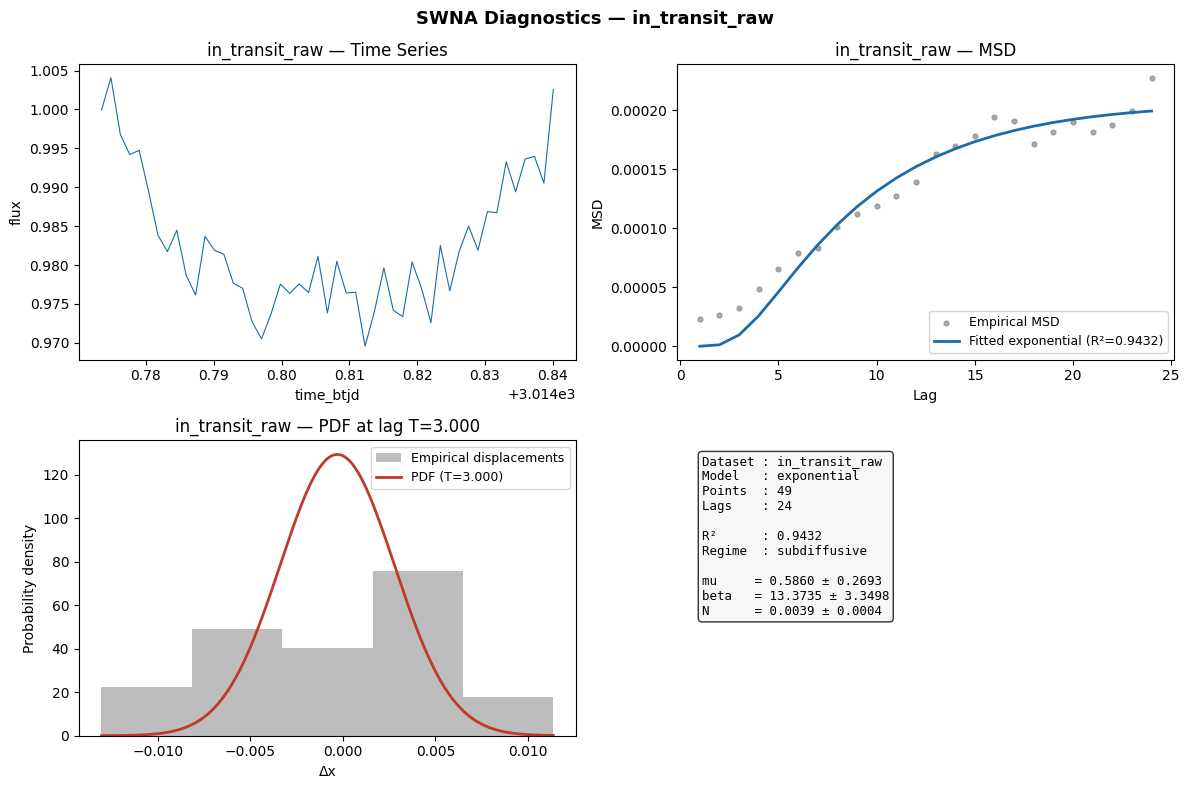

In [15]:
result = wn.analyze(MY_FILE, model='exponential')
result.summary()
fig = wn.plot_diagnostics(result)
plt.show()

In [ ]:
wn.export_csv(result, 'my_results.csv')
files.download('my_results.csv')

---
## Bonus — Compare multiple datasets
### `wn.compare()`

In [ ]:
uploaded_multi = files.upload()
file_list = list(uploaded_multi.keys())
print(f'Uploaded {len(file_list)} files: {file_list}')

In [ ]:
comparison = wn.compare(file_list, model=MY_MODEL)
wn.print_comparison(comparison)

In [ ]:
fig = wn.publish_comparison(comparison)
plt.show()

---
## Quick Reference

| Step | Function | Input | Output |
|---|---|---|---|
| A | `wn.read_csv(file)` | CSV path | time, values, meta |
| B | `wn.plot_series(time, values)` | arrays | plot |
| C | `wn.compute_msd(values)` | 1D array | lags, msd |
| D | `wn.plot_msd_raw(lags, msd)` | arrays | plot |
| E | `wn.fit_msd(lags, msd, model)` | arrays + model name | FitResult |
| F | `fit.summary()` | FitResult | parameter table |
| — | `wn.get_model(name)` | model name | model info dict |
| I | `wn.analyze(file, model)` | CSV path | AnalysisResult |
| — | `wn.plot_diagnostics(result)` | AnalysisResult | 4-panel figure |
| — | `wn.compare(files, model)` | list of paths | ComparisonResult |
| — | `wn.export_csv(result, path)` | AnalysisResult | CSV file |
| — | `wn.list_models()` | — | model table |

**Preprocessing:** `wn.detrend()` · `wn.normalize()` · `wn.smooth()`

**Models:** `cosine` · `exponential` · `sine` · `fbm`